## Part 1: Import Necessary Libraries
* TensorFlow and Keras are used to build, compile, and train the Convolutional Neural Network (CNN) model.
* NumPy is used to handle numerical operations and manage image data efficiently.
* Matplotlib is used to visualise the training results, including accuracy and loss graphs, as well as model performance.
* Scikit-learn is used to generate evaluation metrics such as the confusion matrix and classification report.
* The MedMNIST library is used to load and manage the BloodMNIST image dataset.






In [ ]:
#Installing the MedMNIST package to load the BloodMNIST image dataset
!pip install medmnist

#TensorFlow and Keras used for building and training the CNN model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

#Early stopping is used to stop training when the validation performance no longer improves
from tensorflow.keras.callbacks import EarlyStopping

#NumPy used for handling image data and numerical operations
import numpy as np

#Matplotlib used for visualising training results and model performance
import matplotlib.pyplot as plt

#Evaluation metrics used to assess the classification performance
from sklearn.metrics import confusion_matrix, classification_report

#Import MedMNIST utilities used to access dataset information
import medmnist
from medmnist import INFO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.5 MB/s eta 0:00:00


## Part 2: Load and Prepare the Image Dataset

In this step, the BloodMNIST dataset is loaded using the MedMNIST library. The dataset is already split into training, validation, and test sets, which makes the data preparation process easier. Basic information such as the number of images and the number of classes is printed so that we can have a better understanding of the dataset. The images are then converted into NumPy arrays and normalised so that they are suitable for training the CNN model.

In [ ]:
#BloodMNIST dataset is selected for the image classification task
data_flag = 'bloodmnist'
info = INFO[data_flag]

#Retrieve the dataset class using the dataset information
DataClass = getattr(medmnist, info['python_class'])

#Load the training, validation, and test sets provided by the dataset
train_dataset = DataClass(split='train', download=True)
val_dataset = DataClass(split='val', download=True)
test_dataset = DataClass(split='test', download=True)

#Print basic information to understand the dataset size and classes
print("Number of training images:", len(train_dataset))
print("Number of validation images:", len(val_dataset))
print("Number of test images:", len(test_dataset))
print("Number of classes:", len(info['label']))
print("'Class Number' & 'Class Name:'", info['label'])


100%|██████████| 35.5M/35.5M [01:28<00:00, 400kB/s]


Number of training images: 11959
Number of validation images: 1712
Number of test images: 3421
Number of classes: 8
'Class Number' & 'Class Name:' {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}


In [ ]:
#Print number of channels in the dataset images
print("Number of image channels:", info['n_channels'])

Number of image channels: 3


The number of image channels shows whether images are grayscale or colour. BloodMNIST uses 3 channels (RGB), which matches the CNN input shape (28, 28, 3).

In [ ]:
# Print a short description of the dataset provided by MedMNIST
print("Dataset description:", info['description'])

Dataset description: The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.


This code prints a brief description of the BloodMNIST dataset. It helps to explain what type of images are used and what the classification task involves.

In [ ]:
#Check one sample image and its label from the training set
sample_image, sample_label = train_dataset[0]

#Convert image to NumPy array to inspect shape
sample_image_np = np.array(sample_image)

#Get class label names from dataset info
class_names = info['label']

print("Sample image shape:", sample_image_np.shape)
print(f"Sample label: {sample_label[0]} ({class_names[str(sample_label[0])]})")

Sample image shape: (28, 28, 3)
Sample label: 7 (platelet)


A sample image is inspected by checking its shape and label to confirm the input format for the CNN. Both the numeric class label and the corresponding class name are displayed to improve readability. This helps verify that the dataset is loaded correctly and matches the expected image dimensions for model training.

In [ ]:
#Convert the dataset images and labels into NumPy arrays
X_train = np.array([img for img, label in train_dataset])
y_train = np.array([label for img, label in train_dataset])

X_val = np.array([img for img, label in val_dataset])
y_val = np.array([label for img, label in val_dataset])

X_test = np.array([img for img, label in test_dataset])
y_test = np.array([label for img, label in test_dataset])

#Scale pixel values from the range 0–255 to 0–1 for better training
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

#Print the shapes of the datasets to confirm preprocessing
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (11959, 28, 28, 3)
y_train shape: (11959, 1)
X_val shape: (1712, 28, 28, 3)
y_val shape: (1712, 1)
X_test shape: (3421, 28, 28, 3)
y_test shape: (3421, 1)


The class labels in the BloodMNIST dataset are provided as integer values representing different categories. In this project, sparse categorical crossentropy is used as the loss function during model training, which allows the CNN to work directly with integer-encoded labels. Therefore, one-hot encoding is not required, making the preprocessing step simpler while remaining suitable for multi-class image classification.

## Step 3: Build the CNN Model

In this step, a Convolutional Neural Network (CNN) is built to classify images from the BloodMNIST dataset. The model uses several Conv2D layers to learn spatial features from the images, such as edges, textures, and patterns. Each convolutional layer is followed by a max pooling layer, which reduces the size of the feature maps and helps keep the most important information. After the feature extraction process, a Flatten layer is used to convert the feature maps into a one-dimensional vector so that they can be passed to fully connected layers. A Dense layer with ReLU activation is used to combine the extracted features for classification, and a Dropout layer is included to help reduce overfitting during training. Finally, the output layer uses the softmax activation function to classify the images into eight different classes.

In [ ]:
#Build the CNN model using a Sequential approach
model = Sequential()

#First convolutional layer to extract basic features
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 3)))
model.add(MaxPooling2D((2, 2)))

#Second convolutional layer to learn more complex features
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

#Third convolutional layer for higher-level feature extraction
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

#Flatten the feature maps into a one-dimensional vector
model.add(Flatten())

#Fully connected layer
model.add(Dense(128, activation='relu'))

#Dropout layer to reduce overfitting
model.add(Dropout(0.3))

#Output layer with 8 neurons for 8 classes
model.add(Dense(8, activation='softmax'))

#Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,792 (432.78 KB)

 Trainable params: 110,792 (432.78 KB)

 Non-trainable params: 0 (0.00 B)

In this step, the CNN model is compiled and trained using the pre-processed dataset. Adam is used because it is stable and usually works well without heavy tuning. Sparse categorical cross-entropy is used because the labels are integers. The model is trained with a maximum of 31 epochs, and EarlyStopping is added to automatically stop training when the validation loss does not improve for several epochs. This helps reduce overfitting and ensures that the best model weights are retained. Training and validation accuracy and loss are plotted to observe the learning trend.

In [ ]:
#Compile the CNN model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Early stopping to stop training when validation loss stops improving
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3, #allows some fluctuation before stopping
    restore_best_weights=True
)

#Train the model using training and validation data
history = model.fit(
    X_train, y_train,
    epochs=31,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)

Epoch 1/31
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.3753 - loss: 1.6463 - val_accuracy: 0.7360 - val_loss: 0.7611
Epoch 2/31
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7143 - loss: 0.7898 - val_accuracy: 0.7792 - val_loss: 0.6118
Epoch 3/31
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7741 - loss: 0.6209 - val_accuracy: 0.8049 - val_loss: 0.5260
Epoch 4/31
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8169 - loss: 0.5255 - val_accuracy: 0.8440 - val_loss: 0.4282
Epoch 5/31
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8229 - loss: 0.4897 - val_accuracy: 0.8516 - val_loss: 0.4004
Epoch 6/31
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8438 - loss: 0.4268 - val_accuracy: 0.8703 - val_loss: 0.3773
Epoch 7/31
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8560 - loss: 0.4131 - val_accuracy: 0.8657 - val_loss: 0.3697
Epoch 8/31
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8659 - loss: 0.3742 - val_accuracy: 0

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Save model to Google Drive
model.save('/content/drive/MyDrive/bloodmnist_cnn_model_2.keras')

print("Model saved to Google Drive.")

Mounted at /content/drive
Model saved to Google Drive.


The trained CNN model is saved after training to preserve the learned weights and architecture. This allows the model to be reused without retraining.

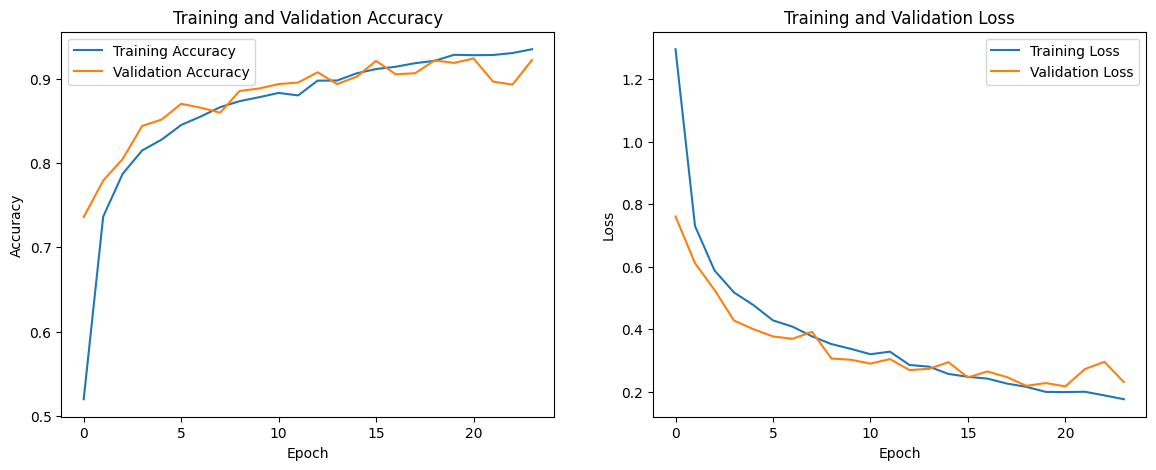

In [ ]:
#Plot training and validation accuracy and loss
plt.figure(figsize=(14, 5))

#Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

#Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

## Part 5: Evaluate the Model
In this step, the trained CNN model is evaluated using the test dataset, which contains unseen images. Test accuracy and loss are used to measure how well the model generalises to new data. Predictions are then generated to further analyse the model's performance using a confusion matrix and a classification report. These evaluation results help provide a better understanding of the strengths and limitations of the trained model.

In [ ]:
#Evaluate the trained model using the test dataset
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 91.64%
Test Loss: 0.2472


In [ ]:
#Generate predictions for test images
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

#Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       244
           1       0.97      0.98      0.98       624
           2       0.99      0.85      0.91       311
           3       0.80      0.85      0.82       579
           4       0.90      0.92      0.91       243
           5       0.83      0.81      0.82       284
           6       0.98      0.94      0.96       666
           7       0.99      1.00      0.99       470

    accuracy                           0.92      3421
   macro avg       0.91      0.90      0.91      3421
weighted avg       0.92      0.92      0.92      3421



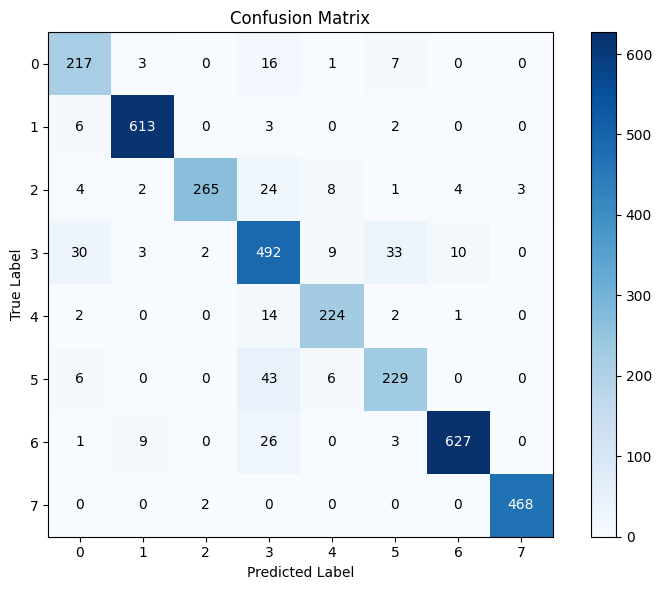

In [ ]:
#Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

#Display values inside the confusion matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()

* Most test images are correctly classified, as shown by the high values along the diagonal of the confusion matrix.
* Several classes, such as class 1, class 6, and class 7, show strong performance with a high number of correct predictions.
* Some misclassifications occur between visually similar blood cell classes.
* For example, images from class 3 are sometimes predicted as class 0 or class 5, indicating overlap in the visual features.
* These errors shows that certain blood cell types are harder for the model to learn and separate correctly.





In [ ]:
# Calculate per class accuracy to see which classes perform better or worse
class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("Per class accuracy:")
for i, acc in enumerate(class_accuracy):
    print(f"Class {i}: {acc:.2f}")

Per class accuracy:
Class 0: 0.89
Class 1: 0.98
Class 2: 0.85
Class 3: 0.85
Class 4: 0.92
Class 5: 0.81
Class 6: 0.94
Class 7: 1.00


Per-class accuracy is calculated from the confusion matrix to identify which classes are easier or harder for the model to classify. This provides a deeper understanding of model performance beyond overall accuracy.

5(a) The trained CNN model was evaluated using the test dataset, which contains unseen BloodMNIST images. The model achieved a test accuracy of 91.17% and a test loss of 0.24, indicating that most of the test images were classified correctly with good confidence.

To further evaluate the model, a confusion matrix was generated. From the confusion matrix, most classes show high correct predictions along the diagonal, which means the model is able to classify many blood cell types correctly. However, there are still some misclassifications between certain blood cell classes that look visually similar, which makes them harder for the model to learn.

In addition, per-class accuracy was calculated to analyse performance at the class level. Some blood cell classes achieved higher accuracy, while others showed lower accuracy, showing that certain categories are more challenging for the model to learn. Overall, these results show that the model performs well on unseen data.

5(b) From the training and validation accuracy curves, the model shows a steady improvement during the early epochs. The training accuracy increases gradually and reaches around 93%, while the validation accuracy follows a similar trend and stabilises at around 92%. The small gap between training and validation accuracy indicates that the model is learning meaningful features rather than memorising the training data.

Both training and validation loss decrease consistently over time. The validation loss shows minor fluctuations after several epochs, but it does not increase sharply or diverge from the training loss. This suggests that the learning process is stable and that the model is able to generalise well to unseen data.

5(c) Based on the training, validation, and test results, the model can be considered well-fitted. The training and validation accuracy curves remain close throughout training, and there is no large gap that would indicate severe overfitting. At the same time, the model achieves a high test accuracy of
91.17%, which shows that it performs well on unseen data.

Although there are small fluctuations in validation loss and per-class accuracy, these are likely due to some blood cell types looking very similar to each other. The use of dropout and early stopping helped reduce overfitting.

## Step 6: Visualize results of correctly and misclassified images

In this step, sample test images are visualised to better understand the CNN model’s predictions. A small number of correctly classified images are displayed to show cases where the model performs well. Misclassified images are also visualised to analyse prediction errors. For misclassified samples, the true label, predicted label, and prediction probability are shown to help explain possible reasons for incorrect predictions.

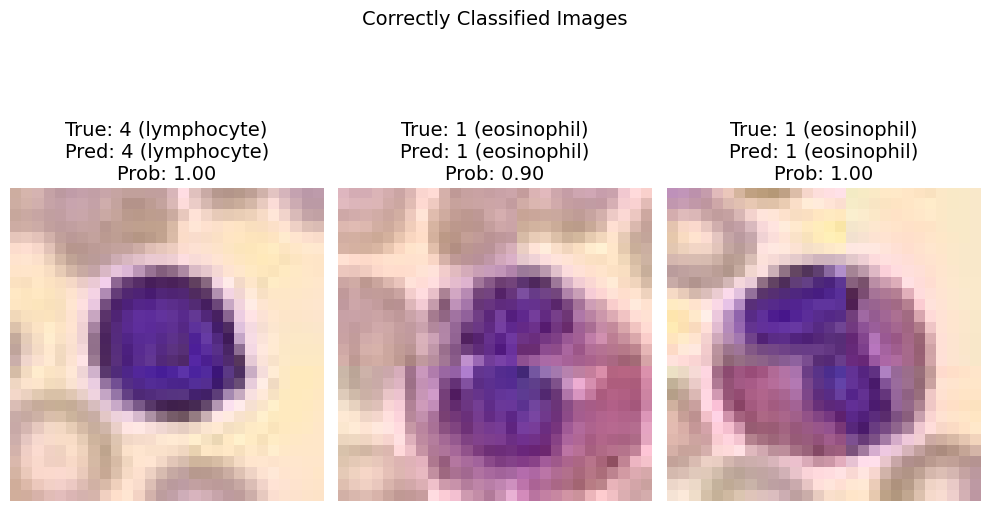

In [ ]:
#Flatten test labels to ensure correct comparison
y_test_flat = y_test.flatten()

#Identify correctly classified samples
correct_indices = np.where(y_pred == y_test_flat)[0]

#Randomly select 3 correctly classified images
selected_correct = np.random.choice(correct_indices, size=3, replace=False)

#Class 3 name is shortened because the original name is too long and causes text overlap
display_class_names = class_names.copy()
display_class_names['3'] = 'Immature Granulocytes'

#Display correctly classified images
plt.figure(figsize=(10, 6))

for i, idx in enumerate(selected_correct):
    plt.subplot(1, 3, i + 1)
    plt.imshow(X_test[idx])

    true_label = int(y_test_flat[idx])
    pred_label = int(y_pred[idx])
    confidence = y_pred_prob[idx][pred_label]

    plt.title(
        f"True: {true_label} ({display_class_names[str(true_label)]})\n"
        f"Pred: {pred_label} ({display_class_names[str(pred_label)]})\n"
        f"Prob: {confidence:.2f}",
        fontsize=14
    )
    plt.axis('off')

plt.suptitle("Correctly Classified Images", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

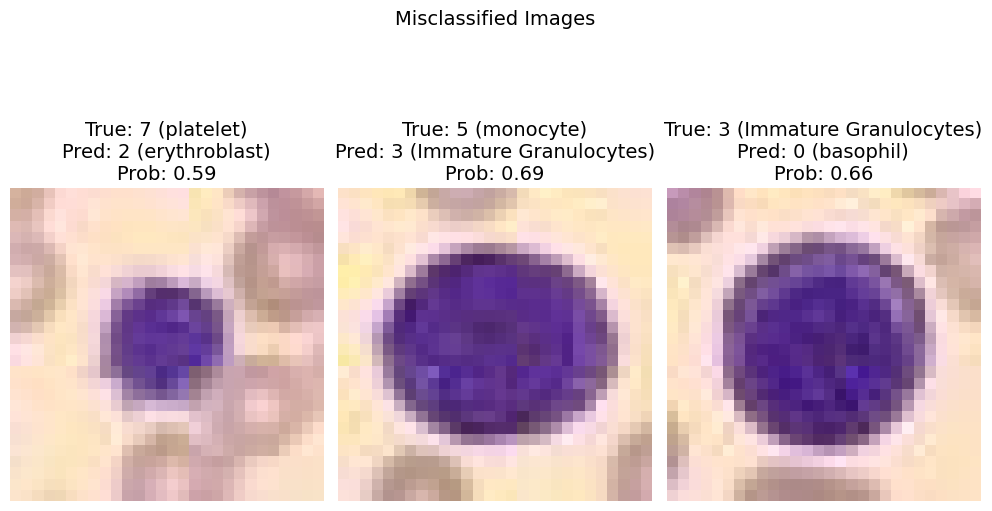

In [ ]:
#Identify misclassified samples
incorrect_indices = np.where(y_pred != y_test_flat)[0]

#Randomly select up to 3 misclassified images
if len(incorrect_indices) >= 3:
    selected_incorrect = np.random.choice(incorrect_indices, size=3, replace=False)
else:
    selected_incorrect = incorrect_indices

#Class 3 name is shortened because the original name is too long and causes text overlap
display_class_names = class_names.copy()
display_class_names['3'] = 'Immature Granulocytes'

#Display misclassified images
plt.figure(figsize=(10, 6))

for i, idx in enumerate(selected_incorrect):
    plt.subplot(1, 3, i + 1)
    plt.imshow(X_test[idx])

    true_label = int(y_test_flat[idx])
    pred_label = int(y_pred[idx])
    confidence = y_pred_prob[idx][pred_label]

    plt.title(
        f"True: {true_label} ({display_class_names[str(true_label)]})\n"
        f"Pred: {pred_label} ({display_class_names[str(pred_label)]})\n"
        f"Prob: {confidence:.2f}",
        fontsize=14
    )
    plt.axis('off')

plt.suptitle("Misclassified Images", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

The misclassified images show that the model sometimes struggles with blood cell classes that look similar in shape and colour. Some incorrect predictions also have high confidence, showing that the model is confusing similar features.

This may be due to the small image size and similarity between some blood cell types. Overall, the visualisations help explain the model's strengths and weaknesses.